# Ahuora Machine Learning Tutorial

This document is intended to give a small taster on machine learning and how it can be used.

As a summary, we introduce the four main parts of building a machine learning model.

1. Clean Data (includes scaling)
2. Build Model incl hyperparameters
3. Train Model
4. Test Model


# import python subpackages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# from keras import layers,regularizers
# from keras.layers import Layer
# from keras import backend as K
# import keras

from sklearn.metrics import mean_squared_error, r2_score
from sklearn import svm, tree
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process import kernels
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPRegressor
from sklearn import preprocessing, model_selection

from sklearn.metrics import r2_score
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.integrate import simpson

from idaes.core.surrogate.pysmo import polynomial_regression, radial_basis_function
from idaes.core.surrogate.pysmo_surrogate import PysmoPolyTrainer
from idaes.core.surrogate.pysmo_surrogate import PysmoRBFTrainer, PysmoSurrogate

# Read in data from a csv

You could generate the data in the same code but it is advised to seperate these.

In [2]:
data_read = pd.read_csv('HP_surrogate_data.csv')

# cols = ['Water_Temperature','Air_Temperature','Heating_Duty','Work_Mechanical','Efficiency','Pressure_Ratio']


## Split data into inputs and outputs
Often in machine learning:
 - Inputs = Features
 - Outputs = Labels

In [3]:
input_cols = ['Water_Temperature','Air_Temperature','Heating_Duty']

output_cols = ['Work_Mechanical','Efficiency','Pressure_Ratio']
# output_cols = ['Work_Mechanical']

inputs = data_read[input_cols]
outputs = data_read[output_cols]

## Remove bad data

In [4]:
# Looking for points that are NaN in outputs
na_inx =  np.array(~outputs.isna().any(axis = 1))

inputs = inputs[na_inx] # must delete corresponding inputs as well!
outputs = outputs[na_inx]


# Choose model type and define functions

### Keras Neural Network

In [ ]:
def train_model(model, train_features, train_labels, verbose = True):
  history = model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=1, epochs=10) # please change these number as appropriate

  if verbose:
    plt.figure()
    plt.semilogy(history.history['loss'], label='loss')
    plt.semilogy(history.history['val_loss'], label='val_loss')
    # plt.ylim([0, 10])
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True)

  return model

def test_model(model, test_features, output_cols):
  model_output = model.predict(test_features)
  model_output = pd.DataFrame(data = model_output, columns = output_cols)
  return model_output

def build_model():
  inputs = keras.Input(shape=(3,)) # how many inputs?

  dense = layers.Dense(20, activation="sigmoid")(inputs) # activation fn?
  dense2 = layers.Dense(20, activation="sigmoid")(dense) # activation fn?
  outputs = layers.Dense(3, activation="relu")(dense2) # how many outputs?

  model = keras.Model(inputs=inputs, outputs=outputs, name="model")

  model.compile(loss='mean_squared_error',
                optimizer=keras.optimizers.Adam(0.001)) # loss metric??
  keras.utils.plot_model(model, show_shapes=True)
  model.summary()
  return model

### SciKit Learn


In [46]:
def train_model(model, train_features, train_labels, verbose = True):
  model.fit(train_features,train_labels)
  return model

def test_model(model, test_features, output_cols):
  model_output = model.predict(test_features)
  model_output = pd.DataFrame(data = model_output, columns = output_cols)
  return model_output

def build_model():
  # model = MultiOutputRegressor(svm.SVR(kernel = 'rbf', degree = 3), n_jobs=3)

  # kernel = 1.0 * kernels.RBF(1.0)
  # model = MultiOutputRegressor(GaussianProcessRegressor(kernel), n_jobs=3)

  # model = MultiOutputRegressor(tree.DecisionTreeRegressor(), n_jobs=3)

  # model = MultiOutputRegressor(RandomForestRegressor(1000), n_jobs=3)

  model = MLPRegressor(batch_size  = 20, max_iter=50000, activation='relu',learning_rate = 'adaptive')

  # model = MultiOutputRegressor(AdaBoostRegressor(n_estimators = 500, base_estimator = tree.DecisionTreeRegressor(max_depth = 10),
  #            learning_rate=0.1 ), n_jobs=3)

  return model

### PySMO 

In [ ]:
# Train function takes the model object and input and output data for the training dataset
# Returns a trained model
def train_model(input_cols, output_cols, train_df, verbose = True):
  # Create the RBF trainer object
  rbf_trainer = PysmoRBFTrainer(input_labels=input_cols, output_labels=output_cols, training_dataframe = train_df)
  rbf_trainer.config.basis_function = 'cubic'
  rbf_train = rbf_trainer.train_surrogate()
  surr = PysmoSurrogate(rbf_train, input_cols, output_cols)

  return surr

# Test function takes the model object and input data for the testing dataset and the names of the output variables so they are not mislabeled
# Returns a output model predictions for the testing dataset
def test_model(model, test_features):
  model_output = model.evaluate_surrogate(test_features)
  return model_output

def build_model():
  model = None
  return model

#### Polynomial - poor performance

In [ ]:
# Train function takes the model object and input and output data for the training dataset
# Returns a trained model
def train_model(model, train_features, train_labels, verbose = True):
  full_data = np.concatenate([train_features, train_labels],axis=1)
  model = polynomial_regression.PolynomialRegression(full_data, full_data, maximum_polynomial_order=3)
  # PysmoPolyTrainer(full_data, full_data, maximum_polynomial_order=3)
  # print(dir(model))
  return model

# Test function takes the model object and input data for the testing dataset and the names of the output variables so they are not mislabeled
# Returns a output model predictions for the testing dataset
def test_model(model, test_features):
  # model_output = model.predict(test_features)
  polyfit = model.polynomial_regression_fitting()
  model_output = model.poly_predict_output(polyfit, test_features)
  return model_output

def build_model():
  model = None
  return model

### OMLT

In [ ]:
# Train function takes the model object and input and output data for the training dataset
# Returns a trained model
def train_model(model, train_features, train_labels, verbose = True):
  model.fit(train_features,train_labels, validation_split=0.2, verbose=1, epochs=100)
  return model

# Test function takes the model object and input data for the testing dataset and the names of the output variables so they are not mislabeled
# Returns a output model predictions for the testing dataset
def test_model(model, test_features):
  model_output = model.predict(test_features)
  return model_output

def build_model():
  activation, optimizer, n_hidden_layers, n_nodes_per_layer = "relu", "Adam", 2, 20
  loss, metrics = "mse", ["mae", "mse"]

  # Create data objects for training using scalar normalization
  model = keras.Sequential()
  model.add(
      keras.layers.Dense(units=n_nodes_per_layer, input_dim=6, activation=activation))
  # Create n hidden layers
  for i in range(1, n_hidden_layers):
      model.add(keras.layers.Dense(units=n_nodes_per_layer, activation=activation))
  model.add(keras.layers.Dense(units=11))

  # Train surrogate (calls optimizer on neural network and solves for weights)
  model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
  return model

## Scaling & Splitting

Generally we do a range scaler, so values are from 0-1
We do this for inputs and outputs and save the scaling variables.

In [47]:
input_scaler = preprocessing.StandardScaler().fit(inputs)
output_scaler = preprocessing.StandardScaler().fit(outputs)

inputs_scaled = input_scaler.transform(inputs)
outputs_scaled = output_scaler.transform(outputs)

# Splitting into training and testing.
# For surrogate modleling it matters little but for real data it is crucial to think it through.

train_inputs, test_inputs = model_selection.train_test_split(inputs_scaled, test_size = 0.8, random_state=5)
train_outputs, test_outputs = model_selection.train_test_split(outputs_scaled, test_size = 0.8, random_state=5)
train_combined = pd.DataFrame(columns = input_cols+ output_cols, data = np.concatenate([train_inputs,train_outputs], axis = 1))
test_inputs_df = pd.DataFrame(columns = input_cols,data = test_inputs)

# Run

In [48]:
model = build_model()
model = train_model(model, train_inputs, train_outputs)
model_output = test_model(model, test_inputs,output_cols) 

# for rbf
# model = train_model(input_cols, output_cols, train_combined)
# model_output = test_model(model, test_inputs_df) 


model_output = output_scaler.inverse_transform(model_output)
test_inputs = input_scaler.inverse_transform(test_inputs)
test_outputs = output_scaler.inverse_transform(test_outputs)
train_inputs = input_scaler.inverse_transform(train_inputs)
train_outputs = output_scaler.inverse_transform(train_outputs)

# for PYSMO

df_model_output = pd.DataFrame(model_output, columns = outputs.columns)
df_test_inputs = pd.DataFrame(test_inputs, columns = inputs.columns)
df_train_inputs = pd.DataFrame(train_inputs, columns = inputs.columns)
df_test_outputs = pd.DataFrame(test_outputs, columns = outputs.columns)
df_train_outputs = pd.DataFrame(train_outputs, columns = outputs.columns)


In [ ]:
full_data = np.concatenate([train_inputs,train_outputs],axis=1)
full_data.shape

# Evaluate


Work_Mechanical
Efficiency
Pressure_Ratio


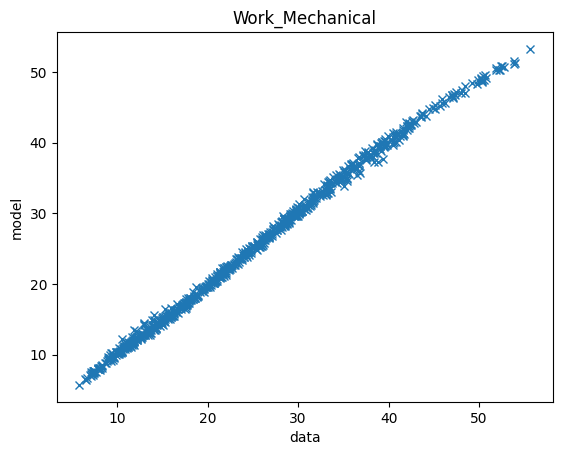

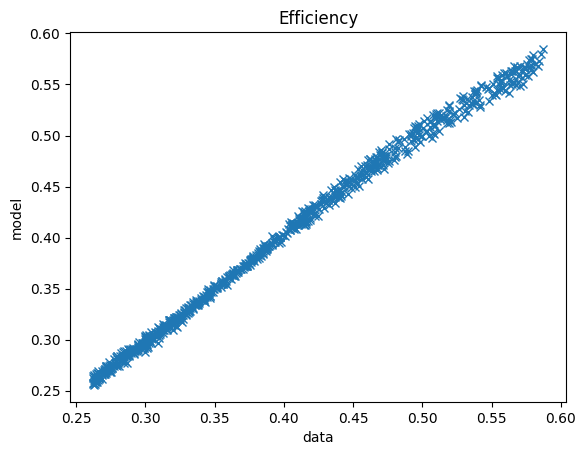

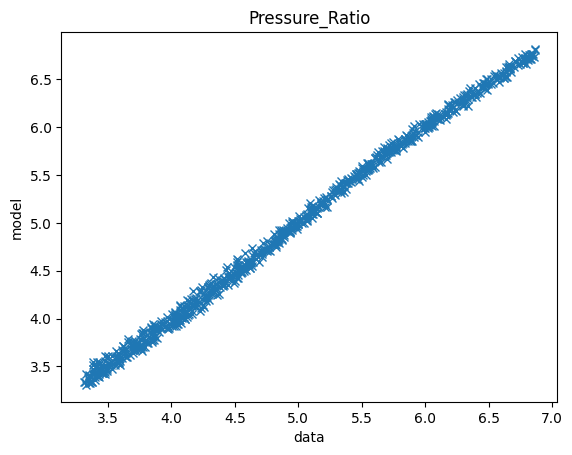

In [49]:
av = np.average([np.average(abs(df_test_outputs[j] - df_model_output[j]))/np.average(df_model_output[j]) for j in df_model_output.columns])   
r2 = np.average([r2_score(df_test_outputs[j], df_model_output[j]) for j in df_model_output.columns]) 
av2 = (abs(df_test_outputs - df_model_output))/np.average(df_model_output)

for i in output_cols:
    print(i)
    plt.figure()
    plt.title(i)
    plt.ylabel('model')
    plt.xlabel('data')
    plt.plot(df_test_outputs[i], df_model_output[i],'x')
    # plt.hist(df_test_outputs[i] - model_output[i], bins=30)
   